In [1]:
from math import sin, cos
from trexdiff import tensor2d
import random

In [2]:
# time horizon -> how many timesteps
T = 50

# difference btwn. timesteps
dt = 1e-1

# gravity
g = 9.81

# that means total time is T * dt
x0 = tensor2d([[0.0], [0.0]])

def f(x, u, dt):
    """x_t+1 given x_t, u_t"""

    a = u[0,0] - g * sin(x[0,0])
    theta_dot_new = x[1,0] + dt * a
    theta_new = x[0,0] + theta_dot_new * dt

    # new state
    return tensor2d([[theta_new], [theta_dot_new]])


def fx(x, u, dt):
    da_dx0 = - g * cos(x[0,0])
    da_dx1 = 0

    dtheta_dot_new_dx0 = dt * da_dx0
    dtheta_dot_new_dx1 = 1 + dt * da_dx1

    dtheta_new_dx0 = 1 + dtheta_dot_new_dx0 * dt
    dtheta_new_dx1 = dtheta_dot_new_dx1 * dt

    return tensor2d([
        [dtheta_new_dx0, dtheta_new_dx1],
        [dtheta_dot_new_dx0, dtheta_dot_new_dx1]
    ])


def fu(x, u, dt):
    da_du = 1
    dtheta_dot_new_du = dt * da_du
    dtheta_new_du = dtheta_dot_new_du * dt

    return tensor2d([[dtheta_new_du], [dtheta_dot_new_du]])


# finite diff check
eps = 1e-6
for i in range(1_000):
    x = tensor2d([[random.uniform(-1, 1)], [random.uniform(-1, 1)]])
    u = tensor2d([[random.uniform(-1, 1)]])

    fx0p = f(x + tensor2d([[eps], [0]]), u, dt)
    fx0m = f(x - tensor2d([[eps], [0]]), u, dt)
    fx1p = f(x + tensor2d([[0], [eps]]), u, dt)
    fx1m = f(x - tensor2d([[0], [eps]]), u, dt)

    fu0p = f(x, u + tensor2d([[eps]]), dt)
    fu0m = f(x, u - tensor2d([[eps]]), dt)

    df_dx0 = (fx0p - fx0m) / (2 * eps)
    df_dx1 = (fx1p - fx1m) / (2 * eps)
    df_du0 = (fu0p - fu0m) / (2 * eps)

    fx_analytic = fx(x, u, dt)
    fu_analytic = fu(x, u, dt)

    assert abs(df_dx0[0,0] - fx_analytic[0,0]) < 1e-5
    assert abs(df_dx0[1,0] - fx_analytic[1,0]) < 1e-5
    assert abs(df_dx1[0,0] - fx_analytic[0,1]) < 1e-5
    assert abs(df_dx1[1,0] - fx_analytic[1,1]) < 1e-5
    assert abs(df_du0[0,0] - fu_analytic[0,0]) < 1e-5

In [3]:
# Qf = 1e4
# loss = Qf * (cos(xs[-1][0]) + 1)
# for u in us:
#     # loss += 1e-2 * relu(u * u  - U_LIM ** 2)
#     loss += 1e-1 * u * u
Qf_weight = 1e4
Qu_weight = 1e-1

def l(xs, us):
    loss = Qf_weight * (cos(xs[-1][0,0]) + 1) +  Qf_weight * (xs[-1][1,0] * xs[-1][1,0])
    for u in us:
        loss += Qu_weight * u * u
    return loss


def hx(x):
    # derivative at final state
    return Qf_weight * tensor2d([[-sin(x[0,0])], [2 * x[1,0]]])

def hxx(x):
    # second derivative at final state
    return Qf_weight * tensor2d([
        [-cos(x[0,0]), 0],
        [0, 2]
    ])

# derivatives at each timestep
def lx(x, u): return tensor2d.zeros(2, 1)
def lxx(x, u): return tensor2d.zeros(2, 2)


def lu(x, u): return 2 * Qu_weight * u
def luu(x, u): return 2 * Qu_weight # * tensor2d([[1]])

def lxu(x, u): return tensor2d.zeros(2, 1)
def lux(x, u): return tensor2d.zeros(1, 2)

In [4]:
xs = [x0]
us = []
for t in range(T):
    u = tensor2d([[5.0]])
    us.append(u)
    xs.append(f(xs[-1], u, dt))

In [5]:
N_iter = 100
print('Initial loss:', l(xs, us)[0,0])
losses = []

Ks = [None] * T
ks = [None] * T

u_reg = 1e-5

for iter in range(N_iter):
    # backward pass
    Vx = hx(xs[-1])
    Vxx = hxx(xs[-1])

    for i in range(T - 1, -1, -1):
        x = xs[i]
        u = us[i]

        # compute Qx, Qu, Qxx, Quu, Qux
        Qx = lx(x, u) + fx(x, u, dt).T @ Vx
        Qu = lu(x, u) + fu(x, u, dt).T @ Vx
        Qxx = lxx(x, u) + fx(x, u, dt).T @ Vxx @ fx(x, u, dt)
        Quu = luu(x, u) + fu(x, u, dt).T @ Vxx @ fu(x, u, dt)
        Qux = lux(x, u) + fu(x, u, dt).T @ Vxx @ fx(x, u, dt)

        # compute k and K
        k = -(1.0/(Quu[0,0] + u_reg)) * Qu
        K = -(1.0/(Quu[0,0] + u_reg)) * Qux

        # store k and K for forward pass
        ks[i] = k
        Ks[i] = K

        # print(T, Quu, Vx, Vxx)

        # update Vx and Vxx
        Vx = Qx + K.T @ Quu @ k + K.T @ Qu + Qux.T @ k
        Vxx = Qxx + K.T @ Quu @ K + K.T @ Qux + Qux.T @ K + u_reg * tensor2d([[1., 0], [0, 1.]])  # regularization

    # forward pass
    loss = l(xs, us)
    best_alpha = 0
    candidate_xs, candidate_us = xs, us


    for alpha_exp in range(25):
        alpha = 1.0 * (0.5 ** alpha_exp)
        xs_new = [x0]
        us_new = []
        for i in range(T):
            x = xs_new[-1]
            u = us[i] + alpha * ks[i] + Ks[i] @ (x - xs[i])
            us_new.append(u)
            xs_new.append(f(x, u, dt))

        loss_new = l(xs_new, us_new)
        if loss_new[0,0] < loss[0,0]:
            candidate_xs = xs_new
            candidate_us = us_new
            loss = loss_new
            best_alpha = alpha
            # print('new best alpha:', alpha, 'loss:', loss_new[0,0])


    xs = candidate_xs
    us = candidate_us

    if best_alpha == 0 and u_reg < 1e3:
        # increase regularization
        u_reg *= 10
        continue

    if best_alpha == 0:
        print(f"iter {iter}, loss: {loss[0,0]:.4f}, no improvement")
        break

    
    if u_reg < 1e-7:
        print('break because u_reg is too small')
        break
    
    u_reg /= 10
    losses.append(loss[0,0])
    print(f"iter {iter}, loss: {loss[0,0]:.4f}, alpha: {best_alpha:.4f}")

Initial loss: 44615.03426272975
iter 0, loss: 19978.0578, alpha: 1.0000
iter 9, loss: 13875.4174, alpha: 0.5000
iter 10, loss: 10439.2351, alpha: 0.0039
iter 11, loss: 5940.1655, alpha: 0.2500
iter 12, loss: 559.1288, alpha: 1.0000
iter 13, loss: 106.5465, alpha: 1.0000
iter 14, loss: 59.9392, alpha: 0.5000
iter 15, loss: 40.2089, alpha: 0.5000
iter 16, loss: 32.2788, alpha: 0.5000
iter 17, loss: 28.1805, alpha: 0.2500
iter 18, loss: 23.4789, alpha: 0.5000
break because u_reg is too small


In [6]:
import matplotlib.animation as animation
import os
from IPython.display import HTML, display
import matplotlib
import matplotlib.pyplot as plt

/tmp/ipykernel_7623/194773374.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'loss')

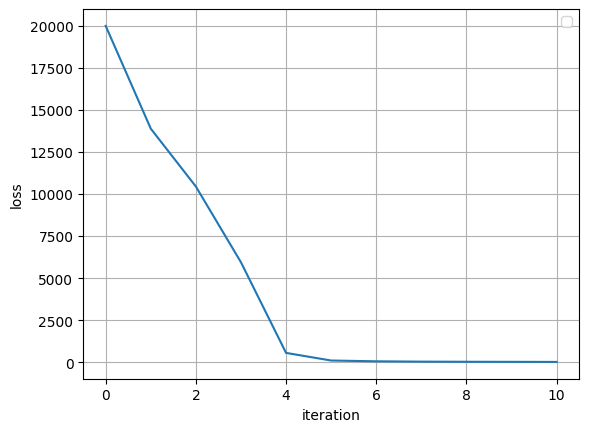

In [7]:
# loss plot
plt.plot(range(len(losses)), losses)
plt.grid()
plt.legend()
plt.xlabel('iteration')
plt.ylabel('loss')

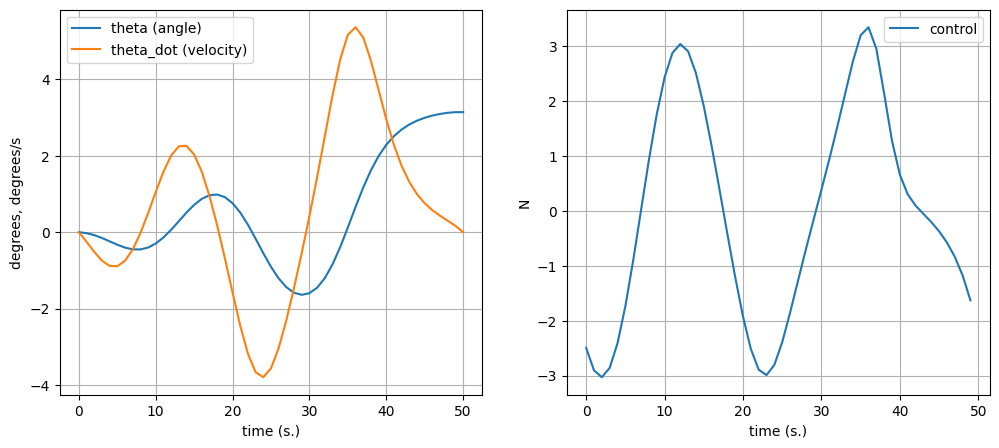

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

# left - theta, theta_dot
ax[0].plot(range(T + 1), [x[0,0] for x in xs], label='theta (angle)')
ax[0].plot(range(T + 1), [x[1,0] for x in xs], label='theta_dot (velocity)')
ax[0].grid()
ax[0].set_xlabel('time (s.)')
ax[0].set_ylabel('degrees, degrees/s')
ax[0].legend()

# right - controls
ax[1].plot(range(T), [u[0,0] for u in us], label='control')
ax[1].grid()
ax[1].set_xlabel('time (s.)')
ax[1].set_ylabel('N')
ax[1].legend()

In [9]:

L = 1.0  # pendulum arm length
thetas = [
    x[0,0] for x in xs
]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title("Pendulum (optimal control)")

rod,       = ax.plot([], [], 'k-', lw=2)
bob,       = ax.plot([], [], 'o', color='steelblue', ms=14)
pivot,     = ax.plot([0], [0], 'k.', ms=8)
time_text  = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9)

# hold final frame for 1 s (20 extra frames at 50 ms each) before looping
HOLD_FRAMES = 20
padded_thetas = thetas + [thetas[-1]] * HOLD_FRAMES

def _init():
    rod.set_data([], [])
    bob.set_data([], [])
    time_text.set_text('')
    return rod, bob, time_text

def _animate(i):
    theta = padded_thetas[i]
    bx = L * sin(theta)
    by = -L * cos(theta)
    rod.set_data([0, bx], [0, by])
    bob.set_data([bx], [by])
    step = min(i, len(thetas) - 1)
    time_text.set_text(f't = {step} steps')
    return rod, bob, time_text

ani = animation.FuncAnimation(
    fig, _animate, init_func=_init,
    frames=len(padded_thetas), interval=50, blit=True
)

os.makedirs("figures", exist_ok=True)
out_path = "figures/pendulum_ilqr.gif"
ani.save(out_path, writer=animation.PillowWriter(fps=20))
print(f"Saved animation")

display(HTML(ani.to_jshtml()))
plt.close(fig)


Saved animation
